In [10]:
# Importando bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Paleta e tema padrão para todos os gráficos
sns.set_theme(style="whitegrid")
PALETTE = ["#C0392B", "#2C3E50", "#E67E22", "#27AE60"]
plt.rcParams["figure.dpi"] = 100

In [ ]:
# Leitura dos dados
df_full  = pd.read_csv("../data/processed/homicidios_brasil_tratado.csv")
df_sinarm = pd.read_csv("../data/processed/sinarm_tratado.csv")

# Preparação dos dados

# Agrega por ano (soma de todos os estados)
df = df_full.groupby("periodo").sum(numeric_only=True).reset_index()

#--- Métricas derivadas ---

# Proporções raciais
df["pct_negros"]    = (df["homicidios_negros"]    / df["homicidios"]).round(4)
df["pct_nao_negros"]= (df["homicidios_nao_negros"] / df["homicidios"]).round(4)

# Proporção de armas de fogo sobre o total
df["pct_armas"] = (df["homicidios_por_armas_de_fogo"] / df["homicidios"]).round(4)

# Taxa de crescimento anual
df["crescimento_homicidios"] = df["homicidios"].pct_change().round(4)

# Média móvel de 3 anos (suaviza ruído)
df["media_movel_3anos"] = df["homicidios"].rolling(3).mean().round(0)

# Integração com SINARM 
df = df.merge(df_sinarm[["periodo", "registros_armas"]], on="periodo", how="left")

# Razão: homicídios com arma de fogo por arma registrada
# Indica "pressão" de cada arma registrada sobre homicídios
df["ratio_homicidios_armas"] = (
    df["homicidios_por_armas_de_fogo"] / df["registros_armas"]
).round(4)


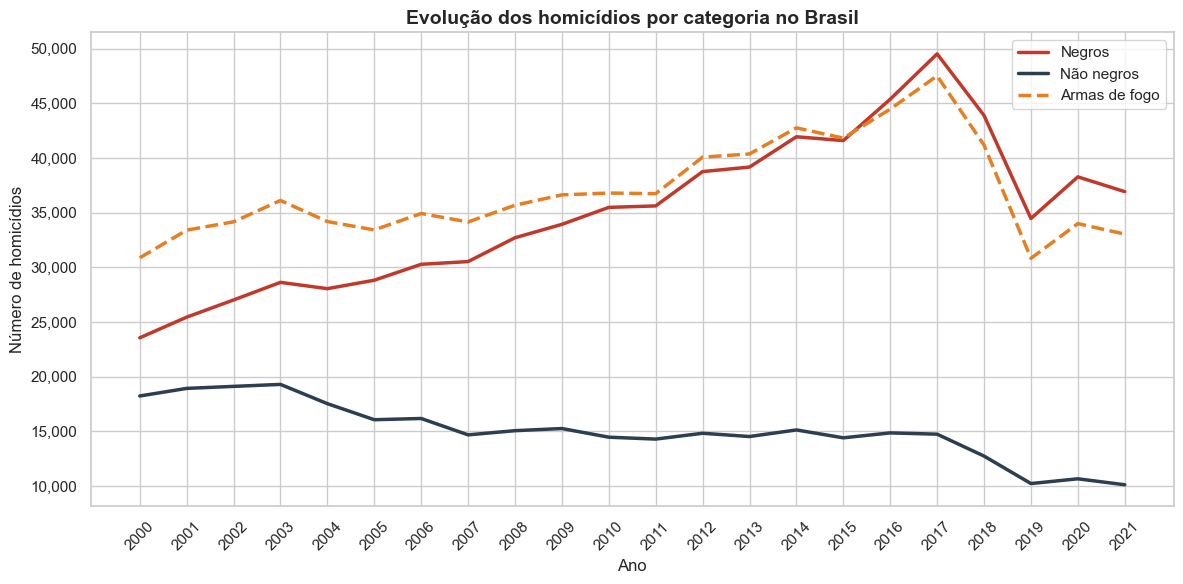

In [12]:
# ============================================
# 1 — Evolução dos homicídios por categoria
# Objetivo: entender qual grupo concentra as mortes
# e se a tendência é de alta ou queda.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df, x="periodo", y="homicidios_negros",
             label="Negros",          color=PALETTE[0], linewidth=2.5, ax=ax)
sns.lineplot(data=df, x="periodo", y="homicidios_nao_negros",
             label="Não negros",      color=PALETTE[1], linewidth=2.5, ax=ax)
sns.lineplot(data=df, x="periodo", y="homicidios_por_armas_de_fogo",
             label="Armas de fogo",   color=PALETTE[2], linewidth=2.5, linestyle="--", ax=ax)

ax.set_title("Evolução dos homicídios por categoria no Brasil", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de homicídios")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

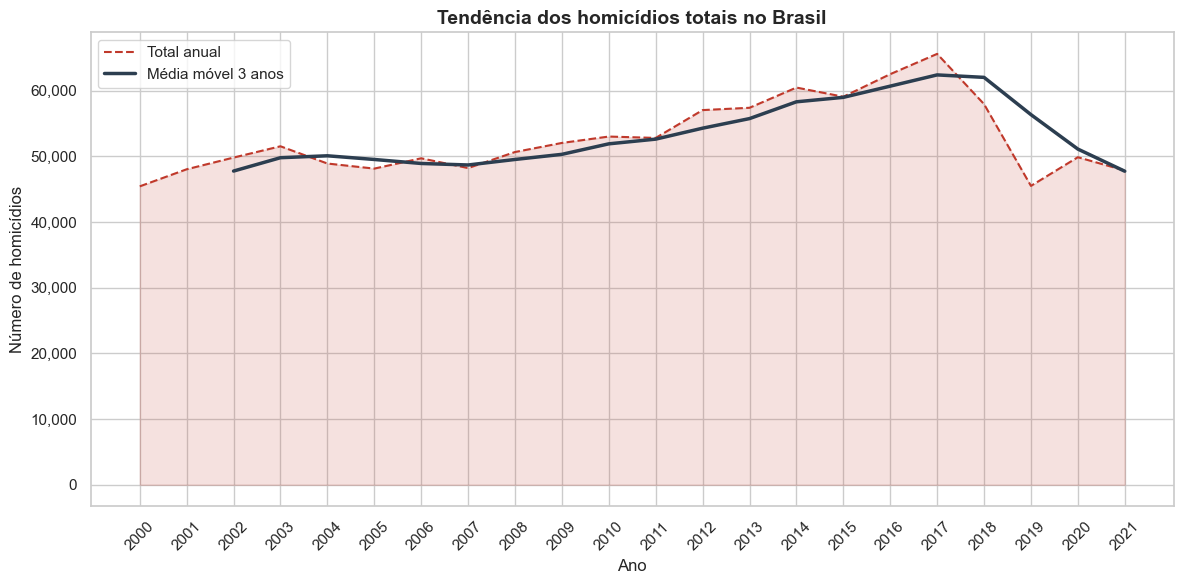

In [13]:
# ============================================
# 2 — Tendência com média móvel
# Objetivo: separar ruído de tendência real.
# A média móvel de 3 anos suaviza variações pontuais
# e revela se o país está em trajetória de queda ou alta.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

# Área sombreada = variação real
ax.fill_between(df["periodo"], df["homicidios"], alpha=0.15, color=PALETTE[0])

sns.lineplot(data=df, x="periodo", y="homicidios",
             label="Total anual",        color=PALETTE[0], linewidth=1.5, linestyle="--", ax=ax)
sns.lineplot(data=df, x="periodo", y="media_movel_3anos",
             label="Média móvel 3 anos", color=PALETTE[1], linewidth=2.5, ax=ax)

ax.set_title("Tendência dos homicídios totais no Brasil", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de homicídios")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

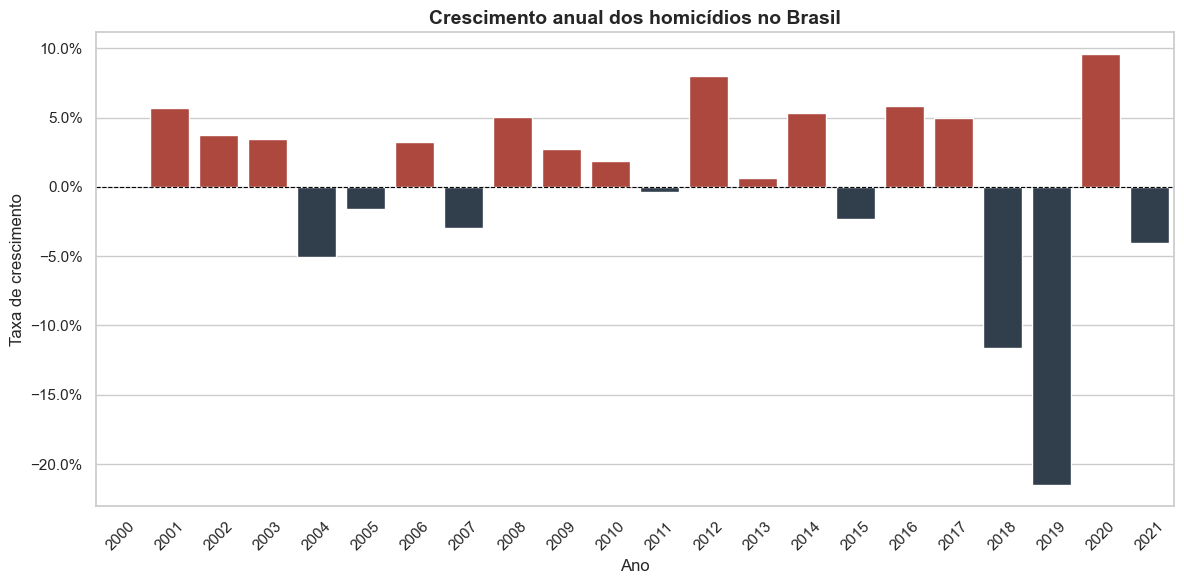

In [14]:
# ============================================
# 3 — Crescimento anual (barras com destaque)
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

# Cria uma coluna auxiliar para o hue (baseada no sinal do crescimento)
df_temp = df.copy()
df_temp["crescimento_sinal"] = df_temp["crescimento_homicidios"].apply(
    lambda x: "positivo" if x >= 0 else "negativo"
)

# Dicionário de cores para cada categoria
paleta_cores = {"positivo": PALETTE[0], "negativo": PALETTE[1]}

sns.barplot(
    data=df_temp, 
    x="periodo", 
    y="crescimento_homicidios",
    hue="crescimento_sinal",
    palette=paleta_cores,
    legend=False,
    ax=ax
)

# Linha de referência no zero
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("Crescimento anual dos homicídios no Brasil", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Taxa de crescimento")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

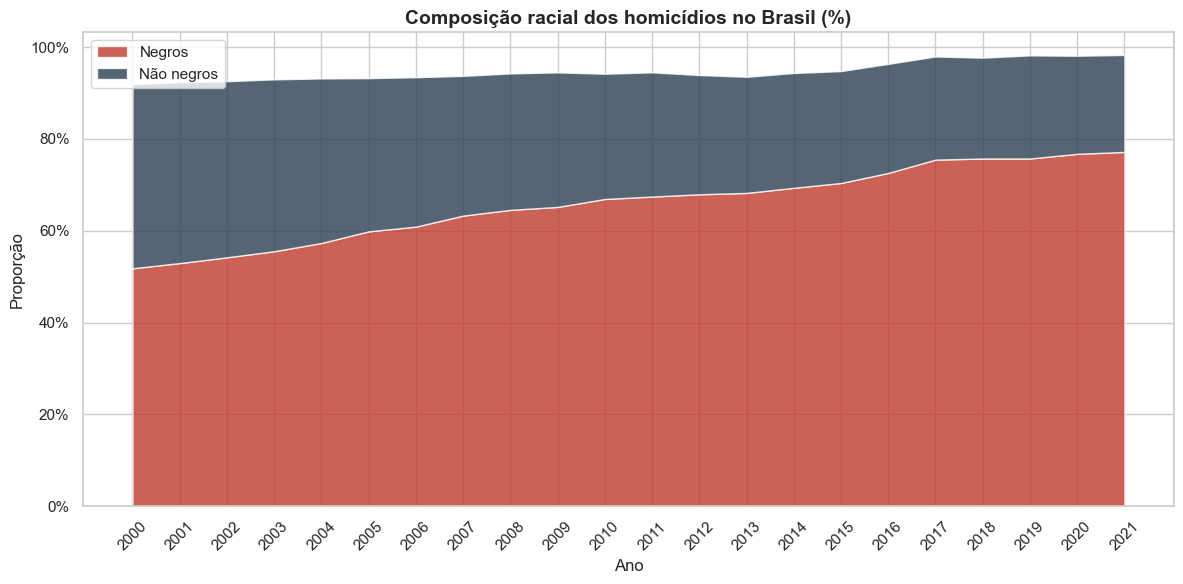

In [15]:
# ============================================
# 4 — Proporção racial ao longo do tempo
# Objetivo: mostrar se a desigualdade racial nos
# homicídios aumentou, diminuiu ou se manteve estável.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

# Área empilhada deixa a proporção mais intuitiva
ax.stackplot(df["periodo"],
             df["pct_negros"], df["pct_nao_negros"],
             labels=["Negros", "Não negros"],
             colors=[PALETTE[0], PALETTE[1]], alpha=0.8)

ax.set_title("Composição racial dos homicídios no Brasil (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Proporção")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

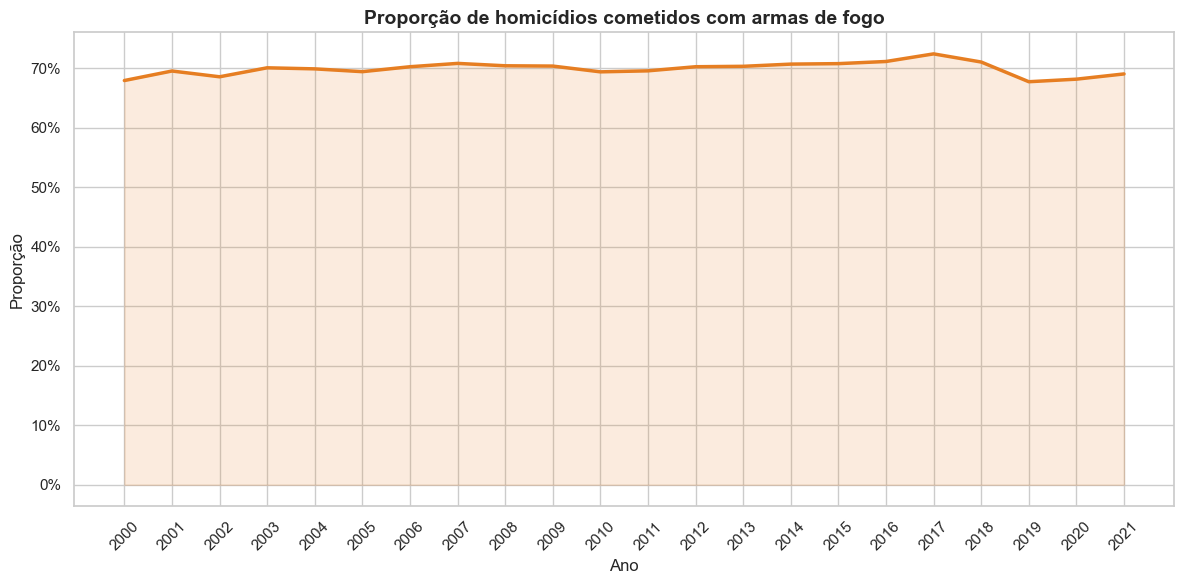

In [16]:
# ============================================
# 5 — Participação de armas de fogo
# Objetivo: ver se armas de fogo ganham ou perdem
# peso relativo nos homicídios ao longo do tempo.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df, x="periodo", y="pct_armas",
             color=PALETTE[2], linewidth=2.5, ax=ax)
ax.fill_between(df["periodo"], df["pct_armas"], alpha=0.15, color=PALETTE[2])

ax.set_title("Proporção de homicídios cometidos com armas de fogo", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Proporção")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

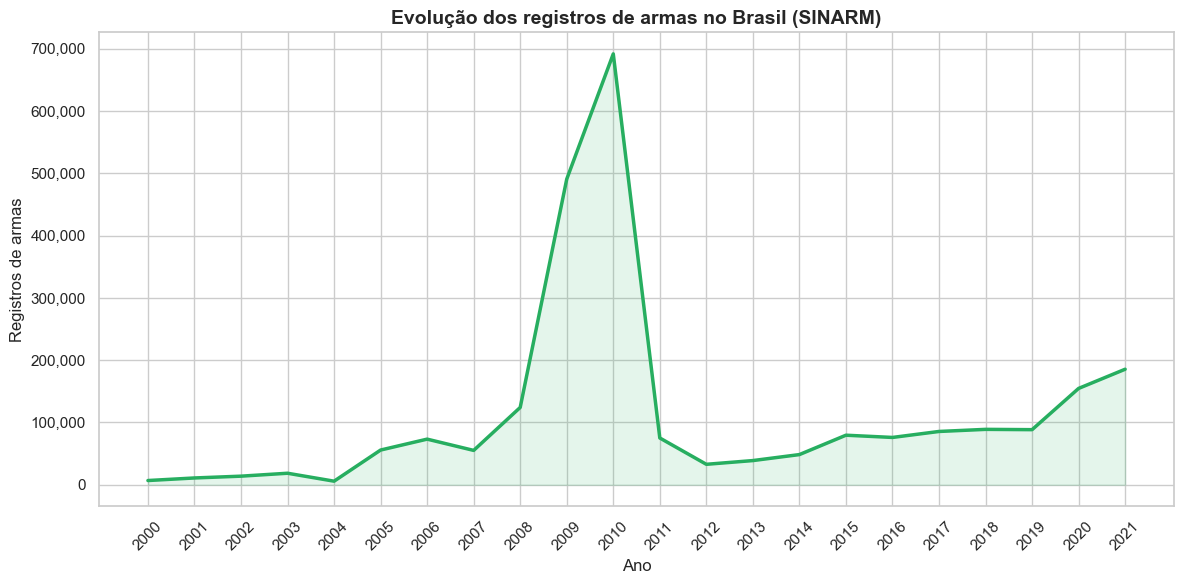

In [17]:
# ============================================
# 6 — Evolução dos registros de armas (SINARM)
# Objetivo: entender se o volume de armas registradas
# cresceu junto com (ou contra) os homicídios.
#
# OBS: O boom de 2009 foi, acima de tudo, causado pelo
# recadastramento obrigatório de armas previsto no
# Estatuto do Desarmamento.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df, x="periodo", y="registros_armas",
             color=PALETTE[3], linewidth=2.5, ax=ax)
ax.fill_between(df["periodo"], df["registros_armas"], alpha=0.12, color=PALETTE[3])

ax.set_title("Evolução dos registros de armas no Brasil (SINARM)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Registros de armas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

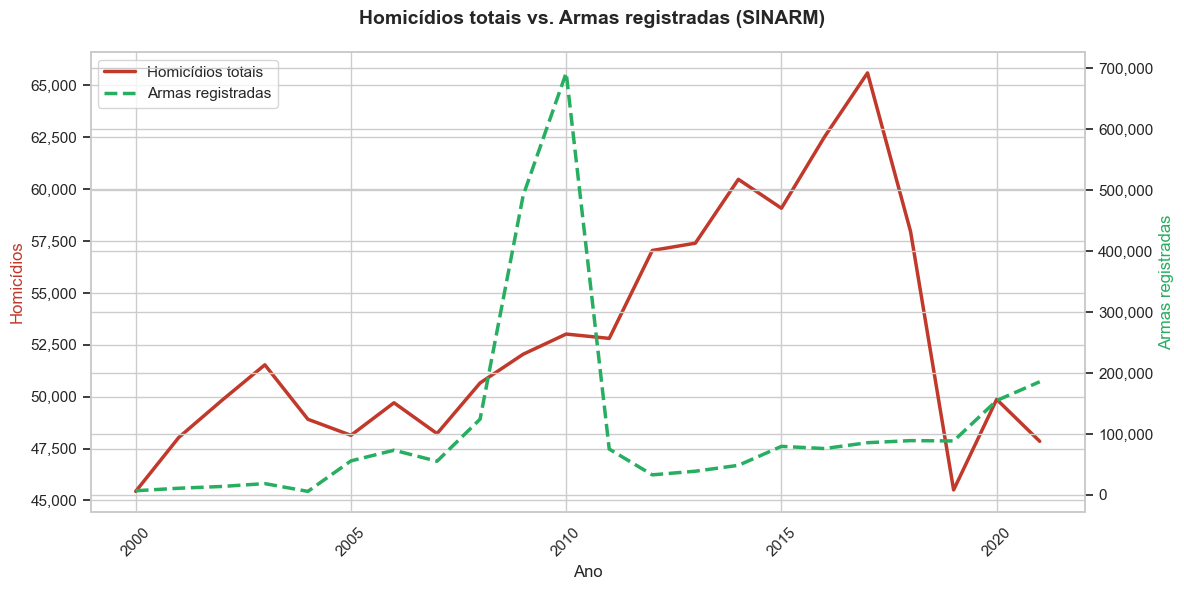

In [18]:
# ============================================
# 7 — Homicídios X Armas Registradas
# Objetivo: comparar diretamente as duas séries
# temporais em escalas diferentes no mesmo gráfico.
# ============================================

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()  # segundo eixo Y compartilhando o eixo X

ax1.plot(df["periodo"], df["homicidios"],
         color=PALETTE[0], linewidth=2.5, label="Homicídios totais")
ax2.plot(df["periodo"], df["registros_armas"],
         color=PALETTE[3], linewidth=2.5, linestyle="--", label="Armas registradas")

ax1.set_xlabel("Ano")
ax1.set_ylabel("Homicídios", color=PALETTE[0])
ax2.set_ylabel("Armas registradas", color=PALETTE[3])

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax1.tick_params(axis="x", rotation=45)

# Legenda unificada dos dois eixos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle("Homicídios totais vs. Armas registradas (SINARM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

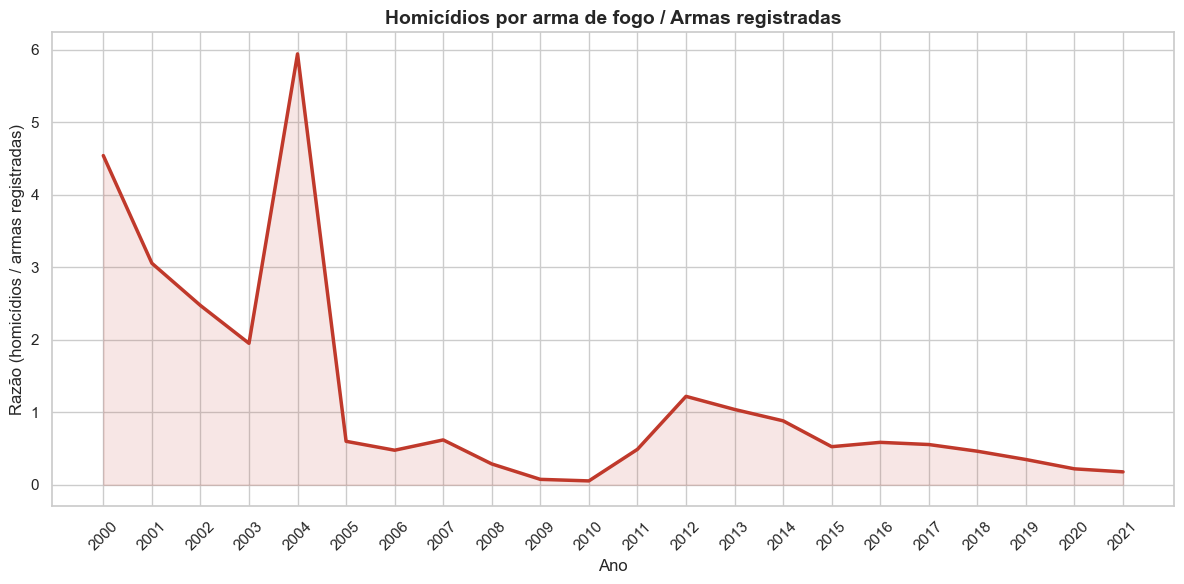

In [19]:
# ============================================
# 8 — Ratio: homicídios por arma de fogo
# por arma registrada
# Objetivo: medir a "eficiência letal" relativa —
# quantos homicídios com arma de fogo ocorrem
# para cada arma registrada no país.
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df, x="periodo", y="ratio_homicidios_armas",
             color=PALETTE[0], linewidth=2.5, ax=ax)
ax.fill_between(df["periodo"], df["ratio_homicidios_armas"], alpha=0.12, color=PALETTE[0])

ax.set_title("Homicídios por arma de fogo / Armas registradas", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Razão (homicídios / armas registradas)")
ax.set_xticks(df["periodo"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()